# Temporal Horizon Detection — Activation Extraction + Linear Probing

Combined notebook: Part 1 (Week 1) extracts residual-stream activations, Part 2 (Week 2)
trains linear probes to locate the temporal subspace.

In-memory handoff eliminates the risk of loading stale `.pt` files between runs.
All outputs still saved to Google Drive for downstream use (Week 3 steering).

# Setup

In [1]:
%%bash
git clone https://github.com/Avi161/temporal-awareness.git
cd temporal-awareness
git checkout research/rq1-week1-extraction
pip install -e '.[dev]' -q

Your branch is up to date with 'origin/research/rq1-week1-extraction'.


fatal: destination path 'temporal-awareness' already exists and is not an empty directory.
Already on 'research/rq1-week1-extraction'


In [2]:
# ── Google Drive persistence ────────────────────────────────────────────────────────────
# Saves out/ to Drive so Week 3 notebook can load outputs without re-running.
import os
from pathlib import Path
from google.colab import drive

drive.mount("/content/drive")

DRIVE_OUT = Path("/content/drive/MyDrive/temporal-awareness-out")
DRIVE_OUT.mkdir(parents=True, exist_ok=True)

LOCAL_OUT = Path("/content/temporal-awareness/out")
if LOCAL_OUT.is_symlink() or LOCAL_OUT.exists():
    LOCAL_OUT.unlink() if LOCAL_OUT.is_symlink() else None
if not LOCAL_OUT.exists():
    LOCAL_OUT.symlink_to(DRIVE_OUT)

print(f"out/ → {DRIVE_OUT}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
out/ → /content/drive/MyDrive/temporal-awareness-out


In [3]:
import os
import sys

os.chdir('/content/temporal-awareness')
sys.path.insert(0, '/content/temporal-awareness')

import json
import pickle
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from tqdm import tqdm

from src.inference import ModelRunner
from src.inference.backends import ModelBackend
from src.intertemporal.common.project_paths import get_experiment_dir
from scripts.week1.activation_extractor import (
    load_implicit_dataset,
    build_prompts,
    extract_activations_for_prompts,
    save_extraction_results,
)

In [5]:
from huggingface_hub import login

# Paste your HF token below — DO NOT commit this cell with the token filled in
login(token=os.environ["HF_TOKEN"])

In [6]:
# Primary model — 16 GB VRAM recommended
# Note: TransformerLens uses "Llama-3.1-8B" (no "Meta-" prefix)
MODEL_NAME = "meta-llama/Llama-3.1-8B"
# MODEL_NAME = "mistralai/Mistral-7B-v0.1"  # fallback if VRAM constrained

DATASET_PATH = Path("data/raw/temporal_scope_AB_randomized/temporal_scope_explicit_expanded_500.json")
OUT_DIR = get_experiment_dir() / "week1_activation_extraction"
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [7]:
runner = ModelRunner(
    MODEL_NAME,
    backend=ModelBackend.TRANSFORMERLENS,
    dtype=torch.float16,
)
print(f"n_layers = {runner.n_layers}")
print(f"d_model  = {runner.d_model}")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading meta-llama/Llama-3.1-8B on cuda (TransformerLens)...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Loaded pretrained model meta-llama/Llama-3.1-8B into HookedTransformer
Model loaded: ModelBackend.TRANSFORMERLENS meta-llama/Llama-3.1-8B (chat=False)
  n_layers=32, d_model=4096

n_layers = 32
d_model  = 4096


─── # Part 1: Activation Extraction (Week 1) ───

## Section 1 — Explicit Dataset (500 pairs)

In [10]:
pairs, metadata = load_implicit_dataset(DATASET_PATH)
print(f"\nLoaded {len(pairs)} pairs")
print("\nFirst pair:")
for p in pairs[:1]:
    print(p)


Loaded 500 pairs

First pair:
{'id': 1, 'category': 'planning', 'question': 'When developing a roadmap for this initiative, consider:', 'immediate': ' (A) What we can deliver in the next 30 days', 'long_term': ' (B) What position we want in 10 years'}


In [12]:
all_names = runner.get_all_names_for_internals()
resid_names = [n for n in all_names if "hook_resid_post" in n]
print(f"Found {len(resid_names)} hook_resid_post layers")
print("First 3:", resid_names[:3])
print("Last 3: ", resid_names[-3:])

Found 32 hook_resid_post layers
First 3: ['blocks.0.hook_resid_post', 'blocks.1.hook_resid_post', 'blocks.2.hook_resid_post']
Last 3:  ['blocks.29.hook_resid_post', 'blocks.30.hook_resid_post', 'blocks.31.hook_resid_post']


In [13]:
test_prompt = immediate_prompts[0]
logits, cache = runner.run_with_cache(
    test_prompt,
    names_filter=lambda n: "hook_resid_post" in n,
)
sample_act = cache["blocks.0.hook_resid_post"][0, -1, :]
print(f"Logits shape:           {logits.shape}")
print(f"Sample activation shape: {sample_act.shape}  (d_model={runner.d_model})")
assert sample_act.shape[0] == runner.d_model, "d_model mismatch"
assert torch.isfinite(sample_act).all(), "Non-finite values in sample activation"
print("Sanity check passed.")

Logits shape:           torch.Size([1, 25, 128256])
Sample activation shape: torch.Size([4096])  (d_model=4096)
Sanity check passed.


In [14]:
acts_immediate = extract_activations_for_prompts(runner, immediate_prompts, desc="Immediate")
print(f"Shape: {acts_immediate.shape}")  # expected [500, n_layers, d_model]

Immediate: 100%|██████████| 500/500 [00:42<00:00, 11.89it/s]

Shape: torch.Size([500, 32, 4096])


In [15]:
acts_long_term = extract_activations_for_prompts(runner, long_term_prompts, desc="Long-term")
print(f"Shape: {acts_long_term.shape}")  # expected [500, n_layers, d_model]

Long-term: 100%|██████████| 500/500 [00:42<00:00, 11.82it/s]

Shape: torch.Size([500, 32, 4096])


In [16]:
save_extraction_results(
    OUT_DIR,
    acts_immediate,
    acts_long_term,
    categories,
    pairs,
    MODEL_NAME,
    DATASET_PATH,
)
print(f"Saved to: {OUT_DIR}")
for f in sorted(OUT_DIR.iterdir()):
    size_mb = f.stat().st_size / 1e6
    print(f"  {f.name:40s}  {size_mb:.1f} MB")

Saved to: /content/temporal-awareness/out/experiments/week1_activation_extraction
  activations_immediate.pt                  131.1 MB
  activations_long_term.pt                  131.1 MB
  metadata.json                             0.0 MB
  pair_metadata.json                        0.0 MB


In [20]:
# Freshness check — confirm files were just written
for fname in ["activations_immediate.pt", "activations_long_term.pt"]:
    fpath = OUT_DIR / fname
    print(f"{fname} last modified: {os.path.getmtime(fpath):.0f}")

activations_immediate.pt last modified: 1773933766
activations_long_term.pt last modified: 1773933766


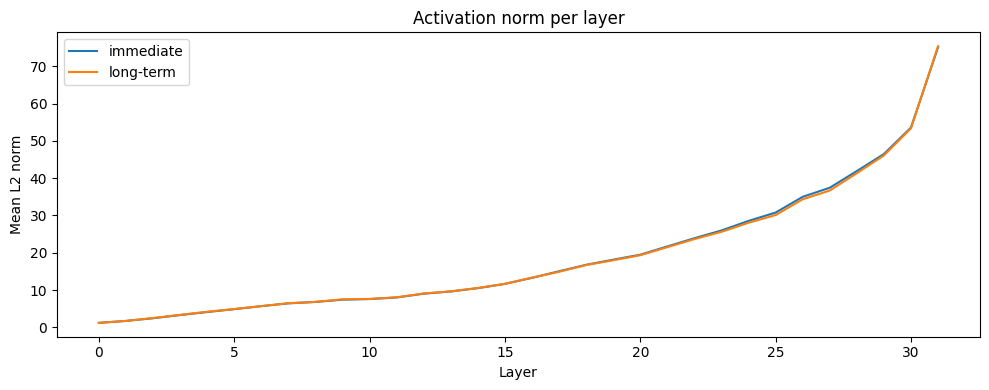

All values finite: OK


In [21]:
# Verification: per-layer L2 norm distribution — should be smooth
norms_imm = acts_immediate.norm(dim=-1).mean(dim=0).cpu()  # [n_layers]
norms_lt  = acts_long_term.norm(dim=-1).mean(dim=0).cpu()

plt.figure(figsize=(10, 4))
plt.plot(norms_imm, label="immediate")
plt.plot(norms_lt,  label="long-term")
plt.xlabel("Layer")
plt.ylabel("Mean L2 norm")
plt.legend()
plt.title("Activation norm per layer")
plt.tight_layout()
plt.show()

# Verify finite values
assert torch.isfinite(acts_immediate).all(), "Non-finite values in acts_immediate"
assert torch.isfinite(acts_long_term).all(), "Non-finite values in acts_long_term"
print("All values finite: OK")

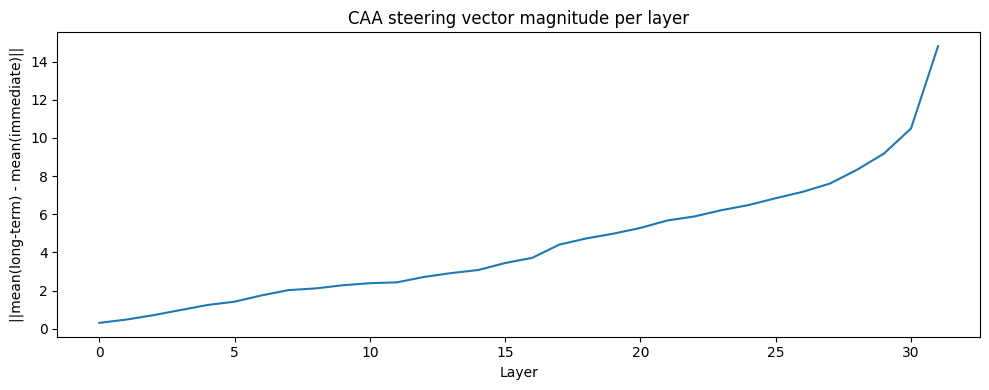

Peak CAA magnitude at layer 31 (of 32)


In [22]:
# Steering vector preview: mean activation difference per layer
# Norm should peak in middle-to-late layers (consistent with interpretability literature)
diff = (acts_long_term - acts_immediate).mean(dim=0)  # [n_layers, d_model]
diff_norms = diff.norm(dim=-1).cpu()

plt.figure(figsize=(10, 4))
plt.plot(diff_norms)
plt.xlabel("Layer")
plt.ylabel("||mean(long-term) - mean(immediate)||")
plt.title("CAA steering vector magnitude per layer")
plt.tight_layout()
plt.show()

peak_layer = diff_norms.argmax().item()
print(f"Peak CAA magnitude at layer {peak_layer} (of {runner.n_layers})")

## Section 2 — Implicit Dataset (300 pairs)

The explicit dataset above uses surface temporal keywords ("next 30 days", "10 years").
Here we repeat the extraction on the **implicit** dataset (300 pairs, no temporal keywords)
and compare side-by-side to see whether the temporal signal is surface-level or semantic.

In [25]:
IMPLICIT_DATASET_PATH = Path("data/raw/temporal_scope_AB_randomized/temporal_scope_implicit_expanded_300.json")
IMPLICIT_OUT_DIR = get_experiment_dir() / "week1_activation_extraction_implicit"
IMPLICIT_OUT_DIR.mkdir(parents=True, exist_ok=True)

pairs_implicit, metadata_implicit = load_implicit_dataset(IMPLICIT_DATASET_PATH)
print(f"\nLoaded {len(pairs_implicit)} pairs")
print("\nFirst pair:")
for p in pairs_implicit[:1]:
    print(p)


Loaded 300 pairs

First pair:
{'id': 1, 'question': 'When the system fails, the first priority becomes', 'immediate': ' (A) containing the spreading damage before it escalates', 'long_term': ' (B) redesigning the architecture to prevent recurrence', 'category': 'crisis_vs_foundation'}


In [26]:
acts_immediate_impl = extract_activations_for_prompts(runner, immediate_prompts_impl, desc="Implicit Immediate")
acts_long_term_impl = extract_activations_for_prompts(runner, long_term_prompts_impl, desc="Implicit Long-term")
print(f"Implicit immediate shape: {acts_immediate_impl.shape}")
print(f"Implicit long-term shape: {acts_long_term_impl.shape}")

assert torch.isfinite(acts_immediate_impl).all(), "Non-finite values in implicit immediate"
assert torch.isfinite(acts_long_term_impl).all(), "Non-finite values in implicit long-term"
print("All values finite: OK")

Implicit Long-term: 100%|██████████| 300/300 [00:25<00:00, 11.71it/s]


Implicit immediate shape: torch.Size([300, 32, 4096])
Implicit long-term shape: torch.Size([300, 32, 4096])
All values finite: OK


In [27]:
save_extraction_results(
    IMPLICIT_OUT_DIR,
    acts_immediate_impl,
    acts_long_term_impl,
    categories_impl,
    pairs_implicit,
    MODEL_NAME,
    IMPLICIT_DATASET_PATH,
)
print(f"Saved to: {IMPLICIT_OUT_DIR}")
for f in sorted(IMPLICIT_OUT_DIR.iterdir()):
    size_mb = f.stat().st_size / 1e6
    print(f"  {f.name:40s}  {size_mb:.1f} MB")

Saved to: /content/temporal-awareness/out/experiments/week1_activation_extraction_implicit
  activations_immediate.pt                  78.6 MB
  activations_long_term.pt                  78.6 MB
  metadata.json                             0.0 MB
  pair_metadata.json                        0.0 MB


In [28]:
# Freshness check — confirm files were just written
for fname in ["activations_immediate.pt", "activations_long_term.pt"]:
    fpath = IMPLICIT_OUT_DIR / fname
    print(f"{fname} last modified: {os.path.getmtime(fpath):.0f}")

activations_immediate.pt last modified: 1773933969
activations_long_term.pt last modified: 1773933969


## Section 3 — Side-by-Side Comparison

**Plot 1** — Activation norm per layer: do both datasets show the same growth pattern?
**Plot 2** — CAA vector magnitude per layer: does the peak shift when temporal keywords are absent?
**Plot 3** — Cosine similarity between the two CAA vectors at each layer: are the directions the same?

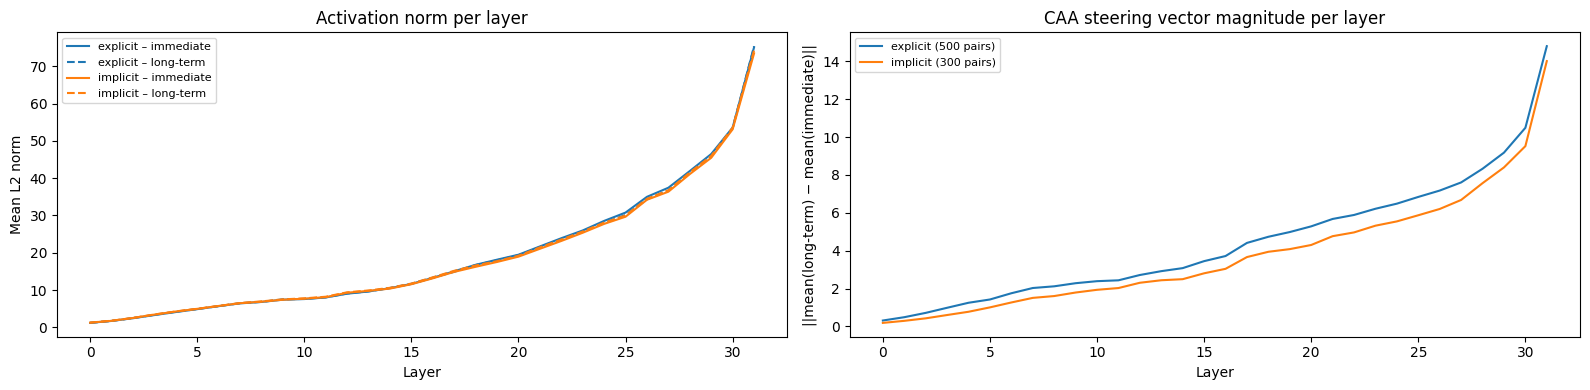

Explicit peak CAA layer: 31  (of 32)
Implicit peak CAA layer: 31  (of 32)


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# --- Plot 1: Activation norm per layer ---
ax = axes[0]
norms_imm_expl = acts_immediate.norm(dim=-1).mean(dim=0).cpu()
norms_lt_expl  = acts_long_term.norm(dim=-1).mean(dim=0).cpu()
norms_imm_impl = acts_immediate_impl.norm(dim=-1).mean(dim=0).cpu()
norms_lt_impl  = acts_long_term_impl.norm(dim=-1).mean(dim=0).cpu()

ax.plot(norms_imm_expl, label="explicit – immediate",  color="tab:blue",   linestyle="-")
ax.plot(norms_lt_expl,  label="explicit – long-term",  color="tab:blue",   linestyle="--")
ax.plot(norms_imm_impl, label="implicit – immediate",  color="tab:orange",  linestyle="-")
ax.plot(norms_lt_impl,  label="implicit – long-term",  color="tab:orange",  linestyle="--")
ax.set_xlabel("Layer")
ax.set_ylabel("Mean L2 norm")
ax.set_title("Activation norm per layer")
ax.legend(fontsize=8)

# --- Plot 2: CAA vector magnitude per layer ---
ax = axes[1]
diff_expl = (acts_long_term - acts_immediate).mean(dim=0)          # [n_layers, d_model]
diff_impl = (acts_long_term_impl - acts_immediate_impl).mean(dim=0)
diff_norms_expl = diff_expl.norm(dim=-1).cpu()
diff_norms_impl = diff_impl.norm(dim=-1).cpu()

ax.plot(diff_norms_expl, label="explicit (500 pairs)", color="tab:blue")
ax.plot(diff_norms_impl, label="implicit (300 pairs)", color="tab:orange")
ax.set_xlabel("Layer")
ax.set_ylabel("||mean(long-term) − mean(immediate)||")
ax.set_title("CAA steering vector magnitude per layer")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

peak_expl = diff_norms_expl.argmax().item()
peak_impl = diff_norms_impl.argmax().item()
print(f"Explicit peak CAA layer: {peak_expl}  (of {runner.n_layers})")
print(f"Implicit peak CAA layer: {peak_impl}  (of {runner.n_layers})")

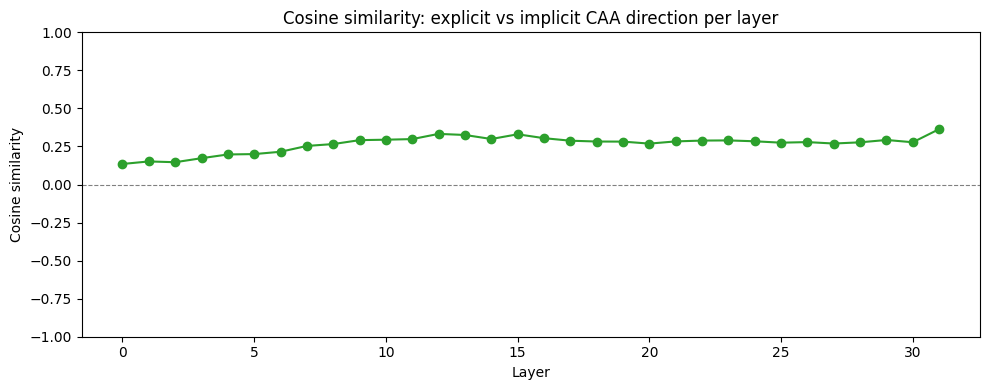

Mean cosine similarity (all layers): 0.266
Max  cosine similarity: 0.364  at layer 31
Min  cosine similarity: 0.135  at layer 0

Interpretation:
  ~1.0  → same temporal direction (semantic, keyword-independent)
  ~0.0  → unrelated directions (explicit driven by surface tokens)
  ~-1.0 → opposite directions (pathological / very different datasets)


In [30]:
# Cosine similarity between the two CAA directions at each layer
# High similarity → the model encodes the same temporal direction regardless of keywords
# Low similarity → explicit keywords drive a different (possibly surface-level) direction

cosine_sims = torch.nn.functional.cosine_similarity(
    diff_expl.float(), diff_impl.float(), dim=-1
).cpu()  # [n_layers]

plt.figure(figsize=(10, 4))
plt.plot(cosine_sims, marker="o", color="tab:green")
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.xlabel("Layer")
plt.ylabel("Cosine similarity")
plt.title("Cosine similarity: explicit vs implicit CAA direction per layer")
plt.ylim(-1, 1)
plt.tight_layout()
plt.show()

print(f"Mean cosine similarity (all layers): {cosine_sims.mean():.3f}")
print(f"Max  cosine similarity: {cosine_sims.max():.3f}  at layer {cosine_sims.argmax().item()}")
print(f"Min  cosine similarity: {cosine_sims.min():.3f}  at layer {cosine_sims.argmin().item()}")
print()
print("Interpretation:")
print("  ~1.0  → same temporal direction (semantic, keyword-independent)")
print("  ~0.0  → unrelated directions (explicit driven by surface tokens)")
print("  ~-1.0 → opposite directions (pathological / very different datasets)")

─── # Part 2: Linear Probing (Week 2) ───

**Why we're doing this:**
Week 1 showed the explicit-dataset CAA vector peaks at Layer 31 — a red flag.
Late layers in transformers typically handle surface token-prediction adjustments,
not abstract semantic content. The cosine similarity between explicit and implicit
CAA directions was only ~0.34, suggesting explicit dataset vectors are contaminated
by surface time-word heuristics.

**Approach (Geometry of Truth methodology):**
- Train a logistic regression probe per layer on the *implicit* dataset
- The layer with the highest test accuracy is where temporal content is encoded semantically
- Zero-shot evaluate those probes on the *explicit* dataset to test generalization
- Redefine the CAA steering vector from implicit dataset means at the best-probe layer

Activations are passed **in-memory** from Part 1 — no stale `.pt` file risk.

## Probing Setup

Configuration for Part 2. Activations are already in memory from Part 1:
- `acts_immediate_impl` / `acts_long_term_impl` — implicit (300 pairs)
- `acts_immediate` / `acts_long_term` — explicit (500 pairs)

In [31]:
OUT_DIR_PROBING = get_experiment_dir() / "week2_probing"
OUT_DIR_PROBING.mkdir(parents=True, exist_ok=True)

# In-memory handoff from Part 1 (no torch.load needed)
n_impl = acts_immediate_impl.shape[0]
n_expl = acts_immediate.shape[0]

N_LAYERS = 32
RANDOM_STATE = 42

print(f"Implicit activations: {acts_immediate_impl.shape} (n={n_impl})")
print(f"Explicit activations: {acts_immediate.shape} (n={n_expl})")
print("Ready for probing.")

Implicit activations: torch.Size([300, 32, 4096]) (n=300)
Explicit activations: torch.Size([500, 32, 4096]) (n=500)
Ready for probing.


## Section 4 — Per-Layer Linear Probing on Implicit Data

For each of the 32 layers:
- Stack immediate (label=0) and long-term (label=1) activations → [600, 4096]
- 80/20 stratified train/test split (random_state=42 for reproducibility)
- Fit LogisticRegression(C=0.1, max_iter=1000) — light L2 regularization per GoT paper
- Record test accuracy and save the trained probe to disk

**Why C=0.1?** The Geometry of Truth paper uses moderate regularization to prevent
overfitting and ensure the probe direction reflects a clean linear feature, not
dataset-specific noise.

In [ ]:
# Build numpy arrays: X [n_impl*2, d_model] per layer, y [n_impl*2]
# Convert float16 → float32 for sklearn
X_impl_np = torch.cat([acts_immediate_impl, acts_long_term_impl], dim=0).float().numpy()
# X_impl_np shape: [600, 32, 4096] — index as [sample, layer, d_model]
y_impl = np.array([0]*n_impl + [1]*n_impl)  # 0=immediate, 1=long_term

layer_results = []

for layer in tqdm(range(N_LAYERS), desc="Probing layers"):
    X_layer = X_impl_np[:, layer, :]   # [600, 4096]

    X_train, X_test, y_train, y_test = train_test_split(
        X_layer, y_impl,
        test_size=0.2, random_state=RANDOM_STATE, stratify=y_impl
    )

    probe = LogisticRegression(C=0.1, max_iter=1000, random_state=RANDOM_STATE)
    probe.fit(X_train, y_train)
    test_acc = probe.score(X_test, y_test)

    # Save probe to disk
    with open(OUT_DIR_PROBING / f"probe_layer_{layer:02d}.pkl", "wb") as f:
        pickle.dump(probe, f)

    layer_results.append({
        "layer": layer,
        "test_accuracy": test_acc,
        "n_train": len(y_train),
        "n_test": len(y_test),
    })

df_probes = pd.DataFrame(layer_results)
df_probes.to_csv(OUT_DIR_PROBING / "probe_accuracies.csv", index=False)
# print(df_probes.to_string(index=False))

Probing layers: 100%|██████████| 32/32 [00:12<00:00,  2.50it/s]

 layer  test_accuracy  n_train  n_test
     0       0.666667      480     120
     1       0.750000      480     120
     2       0.758333      480     120
     3       0.808333      480     120
     4       0.816667      480     120
     5       0.808333      480     120
     6       0.850000      480     120
     7       0.875000      480     120
     8       0.883333      480     120
     9       0.908333      480     120
    10       0.908333      480     120
    11       0.916667      480     120
    12       0.925000      480     120
    13       0.891667      480     120
    14       0.900000      480     120
    15       0.908333      480     120
    16       0.891667      480     120
    17       0.900000      480     120
    18       0.908333      480     120
    19       0.900000      480     120
    20       0.900000      480     120
    21       0.908333      480     120
    22       0.900000      480     120
    23       0.908333      480     120
    24       0.900000    

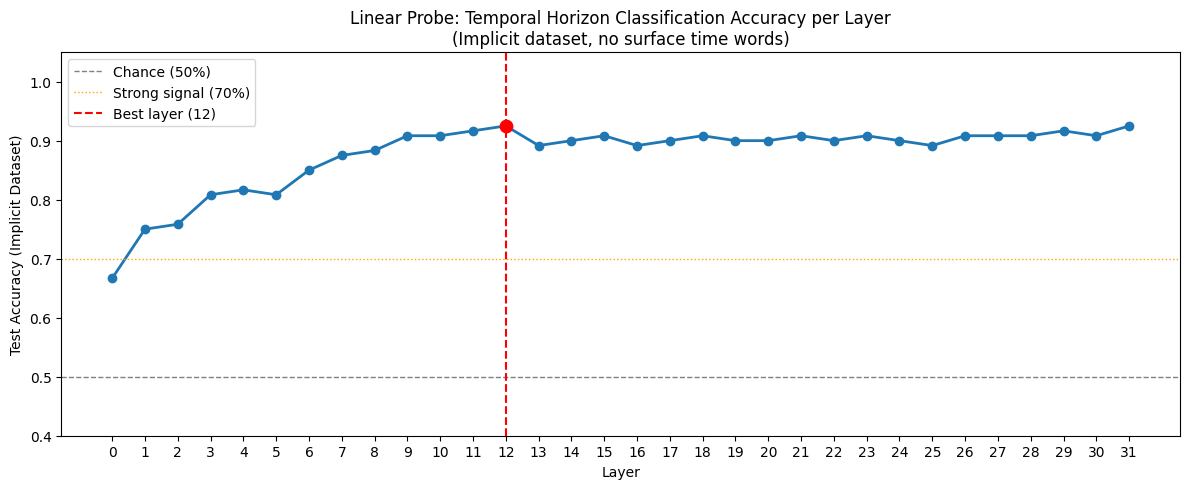


Best layer: 12  |  Test accuracy: 0.925

Top 5 layers:
 layer  test_accuracy  n_train  n_test
    12       0.925000      480     120
    31       0.925000      480     120
    11       0.916667      480     120
    29       0.916667      480     120
     9       0.908333      480     120


In [33]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_probes["layer"], df_probes["test_accuracy"], marker="o", linewidth=2, color="tab:blue")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Chance (50%)")
ax.axhline(0.7, color="orange", linestyle=":", linewidth=1, label="Strong signal (70%)")

best_layer = int(df_probes.loc[df_probes["test_accuracy"].idxmax(), "layer"])
best_acc   = df_probes.loc[df_probes["test_accuracy"].idxmax(), "test_accuracy"]
ax.axvline(best_layer, color="red", linestyle="--", linewidth=1.5, label=f"Best layer ({best_layer})")
ax.scatter([best_layer], [best_acc], color="red", zorder=5, s=80)

ax.set_xlabel("Layer")
ax.set_ylabel("Test Accuracy (Implicit Dataset)")
ax.set_title("Linear Probe: Temporal Horizon Classification Accuracy per Layer\n(Implicit dataset, no surface time words)")
ax.legend()
ax.set_ylim(0.4, 1.05)
ax.set_xticks(range(N_LAYERS))
plt.tight_layout()
plt.savefig(OUT_DIR_PROBING / "probe_accuracy_per_layer.png", dpi=150)
plt.show()

print(f"\nBest layer: {best_layer}  |  Test accuracy: {best_acc:.3f}")
print("\nTop 5 layers:")
print(df_probes.nlargest(5, "test_accuracy").to_string(index=False))

In [ ]:
# Freshness check — confirm probes were just written
for fname in ["probe_accuracies.csv", "probe_accuracy_per_layer.png"]:
    fpath = OUT_DIR_PROBING / fname
    print(f"{fname} last modified: {os.path.getmtime(fpath):.0f}")

## Section 5 — Zero-Shot Cross-Dataset Generalization

We take the probes trained **only on implicit data** and evaluate them on the explicit
dataset — probes never saw any explicit time words during training.

**What this tells us:**
- High cross-dataset accuracy → the probe learned a genuinely semantic temporal direction
- Low cross-dataset accuracy → the probe learned something specific to the implicit dataset's
  linguistic patterns, not a universal temporal concept
- The difference between implicit test accuracy and cross-dataset accuracy measures
  how much of the temporal signal is surface-level vs. semantic

In [ ]:
X_expl_np = torch.cat([acts_immediate, acts_long_term], dim=0).float().numpy()
y_expl    = np.array([0]*n_expl + [1]*n_expl)

cross_accs = []
for layer in tqdm(range(N_LAYERS), desc="Cross-dataset eval"):
    with open(OUT_DIR_PROBING / f"probe_layer_{layer:02d}.pkl", "rb") as f:
        probe = pickle.load(f)
    X_layer_expl = X_expl_np[:, layer, :]
    cross_acc = probe.score(X_layer_expl, y_expl)
    cross_accs.append(cross_acc)

df_probes["cross_dataset_accuracy"] = cross_accs
df_probes.to_csv(OUT_DIR_PROBING / "probe_accuracies.csv", index=False)

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_probes["layer"], df_probes["test_accuracy"],
        marker="o", label="Implicit test accuracy", color="tab:blue")
ax.plot(df_probes["layer"], df_probes["cross_dataset_accuracy"],
        marker="s", label="Explicit cross-dataset accuracy", color="tab:orange", linestyle="--")
ax.axhline(0.5, color="gray", linestyle=":", linewidth=1, label="Chance (50%)")
ax.axvline(best_layer, color="red", linestyle="--", linewidth=1.5, alpha=0.6,
           label=f"Best probe layer ({best_layer})")

ax.set_xlabel("Layer")
ax.set_ylabel("Accuracy")
ax.set_title("Probe Accuracy: Implicit (train/test) vs Explicit (zero-shot generalization)")
ax.legend()
ax.set_ylim(0.4, 1.05)
ax.set_xticks(range(N_LAYERS))
plt.tight_layout()
plt.savefig(OUT_DIR_PROBING / "probe_generalization.png", dpi=150)
plt.show()

print(f"\nAt best probe layer ({best_layer}):")
print(f"  Implicit test accuracy:          {df_probes.loc[best_layer, 'test_accuracy']:.3f}")
print(f"  Explicit cross-dataset accuracy: {df_probes.loc[best_layer, 'cross_dataset_accuracy']:.3f}")
generalization_gap = (df_probes.loc[best_layer, 'test_accuracy']
                      - df_probes.loc[best_layer, 'cross_dataset_accuracy'])
print(f"  Generalization gap:              {generalization_gap:.3f}")

## Section 6 — Redefine the CAA Steering Vector

We now compute the Contrastive Activation Addition vector strictly from the
**implicit** dataset means at the best probe layer.

This is the principled choice because:
1. The best probe layer is where temporal content is most linearly separable
2. The implicit dataset has no surface time words, so the direction captures
   *semantic* temporal reasoning rather than surface token patterns
3. Unit-normalisation makes the vector scale-agnostic for steering strength control

This replaces the Layer 31 explicit-dataset vector from Week 1.

In [ ]:
# Implicit CAA vector at every layer (for reference) and at the best layer (for steering)
diff_impl_all = (acts_long_term_impl.float() - acts_immediate_impl.float()).mean(dim=0)  # [32, 4096]
caa_norms_impl = diff_impl_all.norm(dim=-1)  # [32]

# Select best-probe layer
caa_vec_raw = diff_impl_all[best_layer]                   # [4096]
caa_vec_unit = caa_vec_raw / caa_vec_raw.norm().clamp(min=1e-8)  # unit norm

print(f"Best probe layer: {best_layer}")
print(f"Raw CAA vector norm at layer {best_layer}: {caa_vec_raw.norm():.4f}")
print(f"Unit vector norm: {caa_vec_unit.norm():.6f}")

# Plot CAA magnitude per layer for implicit dataset
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(caa_norms_impl.numpy(), marker="o", color="tab:orange", label="Implicit CAA magnitude")
ax.axvline(best_layer, color="red", linestyle="--", linewidth=1.5,
           label=f"Best probe layer ({best_layer})")
ax.set_xlabel("Layer")
ax.set_ylabel("||mean(long-term) − mean(immediate)||")
ax.set_title("Implicit-Dataset CAA Vector Magnitude per Layer")
ax.legend()
ax.set_xticks(range(N_LAYERS))
plt.tight_layout()
plt.savefig(OUT_DIR_PROBING / "implicit_caa_magnitude.png", dpi=150)
plt.show()

# Save the steering vector
torch.save(caa_vec_unit, OUT_DIR_PROBING / "implicit_caa_vector_unit.pt")
np.save(OUT_DIR_PROBING / "implicit_caa_vector_unit.npy", caa_vec_unit.numpy())

# Save metadata
meta = {
    "best_probe_layer": best_layer,
    "implicit_test_accuracy": float(df_probes.loc[best_layer, "test_accuracy"]),
    "explicit_cross_accuracy": float(df_probes.loc[best_layer, "cross_dataset_accuracy"]),
    "raw_caa_norm": float(caa_vec_raw.norm()),
    "vector_shape": list(caa_vec_unit.shape),
    "dataset": "temporal_scope_implicit_expanded_300",
    "n_implicit_pairs": n_impl,
    "note": "Unit-norm implicit CAA vector at best-probe layer. Use for Week 3 steering."
}
with open(OUT_DIR_PROBING / "steering_vector_meta.json", "w") as f:
    json.dump(meta, f, indent=2)
print(f"\nSaved to: {OUT_DIR_PROBING}")
for p in sorted(OUT_DIR_PROBING.iterdir()):
    print(f"  {p.name:45s}  {p.stat().st_size/1e3:.1f} KB")

In [ ]:
# Freshness check — confirm steering vector was just written
for fname in ["implicit_caa_vector_unit.pt", "steering_vector_meta.json"]:
    fpath = OUT_DIR_PROBING / fname
    print(f"{fname} last modified: {os.path.getmtime(fpath):.0f}")

## Part 3: CAA Steering 


**Goal:** Verify that the CAA direction found in Week 2 actually shifts generation toward longer or shorter temporal horizons.

**In-memory handoff:** activations and the `caa_vec_unit` vector are already computed above — no Drive reload needed.

**What we do:**
1. Compute per-layer CAA unit vectors (using implicit activations from Part 1)
2. Sweep prompts × strengths × conditions (baseline / long-term / short-term)
3. Optionally run a quantitative binary-choice logprob sweep
4. All behaviour is controlled by the **config cell immediately below**

In [41]:
# ═══════════════════════════════════════════════════════════════════════════════
# WEEK 3 CONFIGURATION — edit this cell to control the steering experiment
# ═══════════════════════════════════════════════════════════════════════════════

# ── 1. Steering mode ─────────────────────────────────────────────────────────
# "single" → steer one layer only  (uses W3_STEER_LAYER)
# "multi"  → steer multiple layers simultaneously  (uses W3_STEER_LAYERS)
W3_STEERING_MODE = "single"

# ── 2. Layer selection ───────────────────────────────────────────────────────
# Single-layer mode: which layer to steer.
# Defaults to best_layer from Week 2; override with any integer e.g. 14
W3_STEER_LAYER = best_layer          # Week-2 best probe layer (recommended)

# Multi-layer mode: list of layers steered simultaneously.
# Each layer uses its own per-layer CAA unit vector at FULL strength
# (not divided by n_layers — splitting weakens the signal too much).
W3_STEER_LAYERS = [10, 12, 14]

# ── 3. Steering strengths ────────────────────────────────────────────────────
# Expressed as fractions of the mean residual norm at W3_STEER_LAYER.
# 0.10 = 10% of the typical activation magnitude  →  moderate nudge.
# Set W3_STRENGTHS_ABSOLUTE to a list to bypass fractions entirely.
W3_STRENGTHS_FRAC     = [0.05, 0.10, 0.20, 0.40]   # try 40% for a strong push
W3_STRENGTHS_ABSOLUTE = None          # e.g. [5.0, 10.0, 20.0] — overrides frac

# ── 4. Prompt selection ───────────────────────────────────────────────────────
# PROMPT_SET: "neutral" (5 prompts), "forcing" (5 prompts), or "both" (10 total)
W3_PROMPT_SET = "both"

# Override with specific 1-based indices to run a subset only.
# e.g. [1, 6] → first neutral + first forcing prompt.
# Set to None to use W3_PROMPT_SET.
W3_SELECTED_PROMPTS = None            # e.g. [1, 2, 6, 7]

# ── 5. Generation settings ────────────────────────────────────────────────────
W3_TEMPERATURE = 0.7      # 0 = greedy (deterministic); higher = more varied
W3_MAX_TOKENS  = 120      # max new tokens per generation

# ── 6. Binary choice evaluation ───────────────────────────────────────────────
W3_RUN_BINARY_CHOICE = True   # set False to skip the logprob P(long-term) sweep

# ── Display (no need to edit) ─────────────────────────────────────────────────
print("Week 3 configuration:")
print(f"  Steering mode  : {W3_STEERING_MODE}")
if W3_STEERING_MODE == "single":
    print(f"  Steer layer    : {W3_STEER_LAYER}")
else:
    print(f"  Steer layers   : {W3_STEER_LAYERS}")
print(f"  Strength fracs : {W3_STRENGTHS_FRAC}  (absolute override: {W3_STRENGTHS_ABSOLUTE})")
print(f"  Prompt set     : {W3_PROMPT_SET}  (selected: {W3_SELECTED_PROMPTS})")
print(f"  Temperature    : {W3_TEMPERATURE}  |  Max tokens: {W3_MAX_TOKENS}")
print(f"  Binary choice  : {W3_RUN_BINARY_CHOICE}")

Week 3 configuration:
  Steering mode  : single
  Steer layer    : 12
  Strength fracs : [0.05, 0.1, 0.2, 0.4]  (absolute override: None)
  Prompt set     : both  (selected: None)
  Temperature    : 0.7  |  Max tokens: 120
  Binary choice  : True


## Section 7 — CAA Vectors (In-Memory)

Build per-layer CAA unit vectors from the implicit activations already in memory.
No Drive reload needed — `acts_immediate_impl` / `acts_long_term_impl` are passed directly from Part 1.

In [42]:
from src.inference.interventions import steering as make_steering_intervention

# ── Resolve which layers we need vectors for ──────────────────────────────────
_all_steer_layers = (
    W3_STEER_LAYERS if W3_STEERING_MODE == "multi"
    else [W3_STEER_LAYER]
)

# ── Per-layer CAA unit vectors ────────────────────────────────────────────────
# acts_immediate_impl / acts_long_term_impl: [n_pairs, n_layers, d_model] (float16)
_acts_imm = acts_immediate_impl.float()    # cast once
_acts_lt  = acts_long_term_impl.float()
n_w3_layers = _acts_imm.shape[1]

w3_caa_units = {}    # layer → np.ndarray [d_model], float32
for L in range(n_w3_layers):
    raw = (_acts_lt[:, L, :] - _acts_imm[:, L, :]).mean(dim=0)
    w3_caa_units[L] = (raw / raw.norm().clamp(min=1e-8)).numpy().astype("float32")

print(f"CAA unit vectors computed for all {n_w3_layers} layers.")
print("\nPer-layer raw CAA norms (steering layers highlighted):")
for L in range(n_w3_layers):
    raw_n = float((_acts_lt[:, L, :] - _acts_imm[:, L, :]).mean(dim=0).norm())
    marker = " ◄" if L in _all_steer_layers else ""
    print(f"  Layer {L:2d}: {raw_n:.4f}{marker}")

# ── Adaptive strengths from W3_STEER_LAYER ────────────────────────────────────
_ref_layer_acts = _acts_imm[:, W3_STEER_LAYER, :]
_mean_resid_norm = float(_ref_layer_acts.norm(dim=-1).mean())

if W3_STRENGTHS_ABSOLUTE is not None:
    W3_STRENGTHS = W3_STRENGTHS_ABSOLUTE
else:
    W3_STRENGTHS = [round(f * _mean_resid_norm, 3) for f in W3_STRENGTHS_FRAC]

print(f"\nMean residual norm at layer {W3_STEER_LAYER}: {_mean_resid_norm:.3f}")
print(f"Resolved strengths: {W3_STRENGTHS}")

# ── Save CAA vector at W3_STEER_LAYER to out/ ─────────────────────────────────
W3_OUT_DIR = get_experiment_dir() / "week3_steering"
W3_OUT_DIR.mkdir(parents=True, exist_ok=True)
_caa_tensor = torch.tensor(w3_caa_units[W3_STEER_LAYER])
torch.save(_caa_tensor, W3_OUT_DIR / f"caa_vec_unit_layer{W3_STEER_LAYER}.pt")
np.save(W3_OUT_DIR / f"caa_vec_unit_layer{W3_STEER_LAYER}.npy", w3_caa_units[W3_STEER_LAYER])
print(f"\nSaved CAA vector (layer {W3_STEER_LAYER}) → {W3_OUT_DIR}")

CAA unit vectors computed for all 32 layers.

Per-layer raw CAA norms (steering layers highlighted):
  Layer  0: 0.1849
  Layer  1: 0.2931
  Layer  2: 0.4250
  Layer  3: 0.6005
  Layer  4: 0.7726
  Layer  5: 1.0039
  Layer  6: 1.2634
  Layer  7: 1.5061
  Layer  8: 1.6030
  Layer  9: 1.7891
  Layer 10: 1.9325
  Layer 11: 2.0255
  Layer 12: 2.3043 ◄
  Layer 13: 2.4382
  Layer 14: 2.4934
  Layer 15: 2.8047
  Layer 16: 3.0409
  Layer 17: 3.6620
  Layer 18: 3.9415
  Layer 19: 4.0817
  Layer 20: 4.2992
  Layer 21: 4.7652
  Layer 22: 4.9636
  Layer 23: 5.3185
  Layer 24: 5.5476
  Layer 25: 5.8711
  Layer 26: 6.2043
  Layer 27: 6.6814
  Layer 28: 7.5650
  Layer 29: 8.3998
  Layer 30: 9.5262
  Layer 31: 14.0125

Mean residual norm at layer 12: 9.308
Resolved strengths: [0.465, 0.931, 1.862, 3.723]

Saved CAA vector (layer 12) → /content/temporal-awareness/out/experiments/week3_steering


## Section 8 — Prompt Library & Selection

Two prompt sets:
- **Neutral** (5): open-ended decision stems, no temporal keywords — tests whether steering shifts framing organically
- **Forcing** (5): direct preference completions — cleaner window into which horizon is activated

`W3_SELECTED_PROMPTS` (config cell) overrides `W3_PROMPT_SET` if set.

In [43]:
_NEUTRAL_PROMPTS = [
    # ── Neutral decision-making (no temporal cues) ──────────────────────────
    'When managing a new project, my primary focus is:',
    'The best way to allocate a sudden surplus of budget is:',
    'When building a team, the most important quality to look for is:',
    'In the face of an unexpected setback, the right response is:',
    'When developing a new skill, the most effective approach is:',
]

_FORCING_PROMPTS = [
    # ── Direct preference-forcing ────────────────────────────────────────────
    'What matters most to me is:',
    'If I could only focus on one thing, it would be:',
    'Above all else, I value:',
    'The thing that guides every decision I make is:',
    'When I think about what I want, the answer is always:',
]

# ── All prompts with tags (1-indexed to match W3_SELECTED_PROMPTS) ────────────
_ALL_PROMPTS = (
    [{'text': p, 'set': 'neutral', 'idx': i + 1}      for i, p in enumerate(_NEUTRAL_PROMPTS)]
    + [{'text': p, 'set': 'forcing', 'idx': i + 6}    for i, p in enumerate(_FORCING_PROMPTS)]
)

# ── Apply config selection ────────────────────────────────────────────────────
if W3_SELECTED_PROMPTS is not None:
    _idx_set = set(W3_SELECTED_PROMPTS)
    W3_ACTIVE_PROMPTS = [p for p in _ALL_PROMPTS if p['idx'] in _idx_set]
elif W3_PROMPT_SET == "neutral":
    W3_ACTIVE_PROMPTS = [p for p in _ALL_PROMPTS if p['set'] == 'neutral']
elif W3_PROMPT_SET == "forcing":
    W3_ACTIVE_PROMPTS = [p for p in _ALL_PROMPTS if p['set'] == 'forcing']
else:  # "both"
    W3_ACTIVE_PROMPTS = _ALL_PROMPTS

print(f"Active prompts ({len(W3_ACTIVE_PROMPTS)}):")
for p in W3_ACTIVE_PROMPTS:
    print(f"  [{p['idx']:2d}] [{p['set']}] {p['text']}")

Active prompts (10):
  [ 1] [neutral] When managing a new project, my primary focus is:
  [ 2] [neutral] The best way to allocate a sudden surplus of budget is:
  [ 3] [neutral] When building a team, the most important quality to look for is:
  [ 4] [neutral] In the face of an unexpected setback, the right response is:
  [ 5] [neutral] When developing a new skill, the most effective approach is:
  [ 6] [forcing] What matters most to me is:
  [ 7] [forcing] If I could only focus on one thing, it would be:
  [ 8] [forcing] Above all else, I value:
  [ 9] [forcing] The thing that guides every decision I make is:
  [10] [forcing] When I think about what I want, the answer is always:


## Section 9 — Steering Sweep

Runs the sweep according to `W3_STEERING_MODE`:

- **single**: adds `caa_unit[W3_STEER_LAYER] * strength` to the residual stream at one layer
- **multi**: adds `caa_unit[L] * strength` at *each* layer in `W3_STEER_LAYERS` at **full** strength (not divided — splitting the budget weakens the signal)

Positive strength → long-term direction; negative → short-term.

In [44]:
def _generate_with_hooks(prompt: str, hook_pairs: list) -> str:
    """Generate text with custom forward hooks active (TransformerLens)."""
    formatted  = runner.apply_chat_template(prompt)
    input_ids  = runner._backend.encode(formatted)
    prompt_len = input_ids.shape[1]
    gen_kwargs = {
        "max_new_tokens":    W3_MAX_TOKENS,
        "do_sample":         W3_TEMPERATURE > 0,
        "temperature":       W3_TEMPERATURE,
        "stop_at_eos":       True,
        "verbose":           False,
        "use_past_kv_cache": False,  # must be False when hooks are active
    }
    with torch.no_grad():
        with runner._model.hooks(fwd_hooks=hook_pairs):
            output_ids = runner._model.generate(input_ids, **gen_kwargs)
    return runner._backend.decode(output_ids[0, prompt_len:]).strip()


def _make_hooks(layers: list[int], direction: float, strength: float) -> list:
    """Build hook pairs for residual-stream addition at each specified layer."""
    pairs = []
    for L in layers:
        vec = torch.tensor(
            w3_caa_units[L] * direction * strength,
            dtype=runner.dtype,
            device=runner.device,
        )
        pairs.append(
            (f"blocks.{L}.hook_resid_post", lambda act, hook=None, v=vec: act + v)
        )
    return pairs


# ── Condition list ─────────────────────────────────────────────────────────────
_steer_layers_active = (
    W3_STEER_LAYERS if W3_STEERING_MODE == "multi" else [W3_STEER_LAYER]
)

W3_CONDITIONS = (
    [("baseline", None)]
    + [(f"LT_{s}",  (+1.0, s)) for s in W3_STRENGTHS]
    + [(f"ST_{s}",  (-1.0, s)) for s in W3_STRENGTHS]
)

# ── Run sweep ──────────────────────────────────────────────────────────────────
W3_RESULTS = []
total = len(W3_ACTIVE_PROMPTS) * len(W3_CONDITIONS)
done  = 0

for pdata in W3_ACTIVE_PROMPTS:
    entry = {"prompt": pdata["text"], "set": pdata["set"], "idx": pdata["idx"], "conditions": {}}

    for label, args in W3_CONDITIONS:
        if args is None:
            # Baseline: plain generate (no hooks)
            text = runner.generate(
                pdata["text"],
                max_new_tokens=W3_MAX_TOKENS,
                temperature=W3_TEMPERATURE,
            )
        else:
            direction, strength = args
            hooks = _make_hooks(_steer_layers_active, direction, strength)
            text  = _generate_with_hooks(pdata["text"], hooks)

        entry["conditions"][label] = text.strip()
        done += 1
        print(f"  [{done:3d}/{total}] prompt={pdata['idx']:2d} ({pdata['set']})  {label}")

    W3_RESULTS.append(entry)

print(f"\nSweep complete ({W3_STEERING_MODE}-layer, layers={_steer_layers_active}).")

  [  1/90] prompt= 1 (neutral)  baseline
  [  2/90] prompt= 1 (neutral)  LT_0.465
  [  3/90] prompt= 1 (neutral)  LT_0.931
  [  4/90] prompt= 1 (neutral)  LT_1.862
  [  5/90] prompt= 1 (neutral)  LT_3.723
  [  6/90] prompt= 1 (neutral)  ST_0.465
  [  7/90] prompt= 1 (neutral)  ST_0.931
  [  8/90] prompt= 1 (neutral)  ST_1.862
  [  9/90] prompt= 1 (neutral)  ST_3.723
  [ 10/90] prompt= 2 (neutral)  baseline
  [ 11/90] prompt= 2 (neutral)  LT_0.465
  [ 12/90] prompt= 2 (neutral)  LT_0.931
  [ 13/90] prompt= 2 (neutral)  LT_1.862
  [ 14/90] prompt= 2 (neutral)  LT_3.723
  [ 15/90] prompt= 2 (neutral)  ST_0.465
  [ 16/90] prompt= 2 (neutral)  ST_0.931
  [ 17/90] prompt= 2 (neutral)  ST_1.862
  [ 18/90] prompt= 2 (neutral)  ST_3.723
  [ 19/90] prompt= 3 (neutral)  baseline
  [ 20/90] prompt= 3 (neutral)  LT_0.465
  [ 21/90] prompt= 3 (neutral)  LT_0.931
  [ 22/90] prompt= 3 (neutral)  LT_1.862
  [ 23/90] prompt= 3 (neutral)  LT_3.723
  [ 24/90] prompt= 3 (neutral)  ST_0.465
  [ 25/90] promp

## Section 10 — Results Display

In [46]:
import json
from IPython.display import display, Markdown

_NL = chr(10)
_mode_label = (
    f"Single-layer L{W3_STEER_LAYER}"
    if W3_STEERING_MODE == "single"
    else f"Multi-layer {_steer_layers_active}"
)


def _abbrev(text: str, n: int = 240) -> str:
    text = " ".join(text.split()).replace("|", "/")
    return text if len(text) <= n else text[:n].rsplit(" ", 1)[0] + "..."


def _render_entry(entry: dict) -> str:
    cond = entry["conditions"]
    rows = [
        "| Condition | Strength | Completion |",
        "|-----------|:--------:|------------|",
        f"| **Baseline** | — | {_abbrev(cond['baseline'])} |",
    ]
    for s in W3_STRENGTHS:
        lt = _abbrev(cond.get(f"LT_{s}", "(missing)"))
        st = _abbrev(cond.get(f"ST_{s}", "(missing)"))
        rows.append(f"| ↑ Long-term  | +{s} | {lt} |")
        rows.append(f"| ↓ Short-term | −{s} | {st} |")
    header = (
        f"### [{entry['set']}] Prompt {entry['idx']}{_NL}{_NL}"
        f"> {entry['prompt']}{_NL}{_NL}"
    )
    return header + _NL.join(rows)


print(f"{'=' * 60}")
print(f"STEERING RESULTS  —  {_mode_label}")
print(f"{'=' * 60}")
for entry in W3_RESULTS:
    display(Markdown(_render_entry(entry)))
    print()

# ── Save to JSON ───────────────────────────────────────────────────────────────
_save_name = (
    f"steering_results_single_L{W3_STEER_LAYER}.json"
    if W3_STEERING_MODE == "single"
    else f"steering_results_multi_{'_'.join(str(l) for l in _steer_layers_active)}.json"
)
_save_data = {
    "mode":              W3_STEERING_MODE,
    "steer_layers":      _steer_layers_active,
    "strengths":         W3_STRENGTHS,
    "strengths_frac":    W3_STRENGTHS_FRAC,
    "mean_resid_norm":   round(_mean_resid_norm, 4),
    "temperature":       W3_TEMPERATURE,
    "results":           W3_RESULTS,
}
with open(W3_OUT_DIR / _save_name, "w") as f:
    json.dump(_save_data, f, indent=2)
print(f"Saved: {W3_OUT_DIR / _save_name}")

STEERING RESULTS  —  Single-layer L12


### [neutral] Prompt 1

> When managing a new project, my primary focus is:

| Condition | Strength | Completion |
|-----------|:--------:|------------|
| **Baseline** | — | 1. Is the project needed? 2. Does the project fit within the business strategy? 3. Is the project feasible? New projects must provide value to the organization. If the project does not provide a positive return on investment, then it... |
| ↑ Long-term  | +0.465 | to ensure that the project is successfully delivered to the customer’s satisfaction, on-time, within budget, and to the agreed-upon scope. This is accomplished through tight project management and customer management: monitoring and... |
| ↓ Short-term | −0.465 | 1) to learn the applicable regulations, 2) to understand the specific requirements of the client, 3) to learn the construction methods to be used, and 4) to learn the personalities of the players. 1. Learn the regulations. There are two... |
| ↑ Long-term  | +0.931 | What are the objectives of the project and how do we measure success? In my experience, the most successful projects have a clear objective and there is a clear way to measure success. Without these, it’s hard to know if you are succeeding... |
| ↓ Short-term | −0.931 | (a) to ensure the project is completed on time; and (b) to make sure it is completed according to plans. Some project managers, however, have a tendency to focus on the completion of the project, and to the detriment of the schedule. This... |
| ↑ Long-term  | +1.862 | and I have decided to use the following method to help me achieve this: . As a designer at , I am primarily responsible for: and in order to achieve my goals, I have developed a unique perspective on . Through my work, I strive to create a... |
| ↓ Short-term | −1.862 | “What are the first things I need to do?” In other words, “What is the minimal amount of effort I can invest to get the most out of the project?” This is a good question to ask in most cases, but there are often circumstances when the... |
| ↑ Long-term  | +3.723 | explaining. We are often awesome at explaining things, and that is the fundamental basis for the work of the new project. The quality of the work depends on the quality of the explanation. I have been a big fan of lean in my own work and... |
| ↓ Short-term | −3.723 | Ensuring the project is completed on time, within budget, and according to the contract. I also check that the project meets the quality standards and specifications. When managing a new project, my primary focus is: Ensuring that all... |

### [neutral] Prompt 2

> The best way to allocate a sudden surplus of budget is:

| Condition | Strength | Completion |
|-----------|:--------:|------------|
| **Baseline** | — | 1. Increase the size of the executive 2. Increase the advertising budget 3. Increase the size of the editorial staff 4. Increase the size of the circulation department 5. Increase the size of the classified advertising department 6.... |
| ↑ Long-term  | +0.465 | 1. to allocate it in a way that is best for the economy and 2. to avoid spending the money in ways that are not. The best way to do this is to set up a transparent process that allows the public to judge the choices made by the government... |
| ↓ Short-term | −0.465 | (1) keep it in the bank, (2) use it to pay off debt, (3) use it to increase the cash reserve, (4) use it to increase the credit line, (5) use it to pay off debt and increase the cash reserve, (6) use it to increase the credit line and... |
| ↑ Long-term  | +0.931 | (1) if it is not needed to cover some short-term need, lend it to the government; (2) if it is needed to cover some short-term need, set it aside for a rainy day. If the government needs money, it should borrow from its citizens, not make... |
| ↓ Short-term | −0.931 | 1. Increase the expenditure on current services. 2. Reduce the excessive expenditure on current services. 3. Increase the sum of the capital account. 4. Reduce the capital expenditure. * [8] Which one of the following is not a part of the... |
| ↑ Long-term  | +1.862 | 1. Allocate it to a short-term time horizon. 2. Allocate it to a strategic time horizon. 3. Allocate it to a long-term time horizon. 4. Allocate it to a very long-term time horizon. 5. The nature of the quarterly cash flow is: 1. A... |
| ↓ Short-term | −1.862 | (a) cut taxes, (b) increase spending, (c) save it for a rainy day, (d) spend it on the common good, or (e) give it to the poor. About 1,000 people replied to the poll on the Facebook page of the Catholic News Service. They were asked to... |
| ↑ Long-term  | +3.723 | ” “16. What is the best way for the public to educate themselves to understand the risks and rewards of cryptocurrencies?” “I don’t know if I can answer that. But I can tell you that there’s going to be a new form of data that’s going to... |
| ↓ Short-term | −3.723 | throw it in the garbage, then write it off as an expense. Why? Because you cannot buy a new car for less money than it cost to buy the old one. And you certainly cannot buy something equally as expensive as something you already have.... |

### [neutral] Prompt 3

> When building a team, the most important quality to look for is:

| Condition | Strength | Completion |
|-----------|:--------:|------------|
| **Baseline** | — | a. Humility b. Charisma c. Intelligence d. Empathy e. None of the above What is the correct order of the evolution of consciousness? a. One is not separate from all that is b. I am connected to all that is c. I am separate from all that is... |
| ↑ Long-term  | +0.465 | ** **A. Experience.** **B. Talent.** **C. Character.** **D. Ability to work together.** **Answer: D** **Explanation:** **When building a team, the most important quality to look for is the ability to work together.** **Character** **A team... |
| ↓ Short-term | −0.465 | 1. The ability to be in the right place at the right time. 2. A proven track record. 3. A proven track record. 4. A good temperament. ## Chapter 18 The Light of the World That is why I say to you: Be wise as snakes and innocent as doves.... |
| ↑ Long-term  | +0.931 | A. the ability to work in a team B. the ability to work independently C. the ability to keep secrets D. a positive attitude Answer: A Explanation: To succeed in science, the most important quality to look for in a team is the ability to... |
| ↓ Short-term | −0.931 | A. A team player B. Conscientiousness C. Integrity D. Initiative Answer: C</end_of_text/> |
| ↑ Long-term  | +1.862 | leadership. The most successful teams are those that are led by people who have the ability to inspire and motivate others. A good leader can help to create a culture of collaboration and innovation, which are essential for building a... |
| ↓ Short-term | −1.862 | A. Leadership. B. The ability to work in a group. C. The ability to be in charge. D. None of the above. Answer: B</end_of_text/> |
| ↑ Long-term  | +3.723 | The right people. When building a team, the most important quality to look for is: The right people. When building a team, the most important quality to look for is: The right people. When building a team, the most important quality to... |
| ↓ Short-term | −3.723 | A. expertise. B. experience. C. loyalty. The salesman who sold the most items last month was: A. Fred. B. Jane. C. Ned. The house on the corner is for sale. Who lives there? A. Fred. B. Jane. C. Ned. The water in the lake is too deep.... |

### [neutral] Prompt 4

> In the face of an unexpected setback, the right response is:

| Condition | Strength | Completion |
|-----------|:--------:|------------|
| **Baseline** | — | “It’s OK to be upset. We’re all disappointed. But we can’t let that stop us from going after our goal. So, what do we need to do to get back on track?” 6. Never give up. Never. When it comes to hiring, there may be a ton of candidates and... |
| ↑ Long-term  | +0.465 | "There is no plan B. There is only Plan A, and it's going to work." ## Chapter 14 Plan A Will Work The most important thing to remember about plan A is that it will work. It is guaranteed, from the very moment you commit to it, to... |
| ↓ Short-term | −0.465 | “That’s okay, it’s not that big of a deal, it’s not the end of the world, and I’m going to keep going. I’m going to keep doing my best, and I’m going to do it again tomorrow.” The right response is not: “I’m never going to be able to do... |
| ↑ Long-term  | +0.931 | What do I DO now? What do I do now, when I can't trust my own intuition? My own feelings? When my own mind has become a toxic container for the most vicious lies? When the lies are so deeply ingrained that I am no longer able to... |
| ↓ Short-term | −0.931 | "I can't believe this is happening! I'm just not going to let this happen." The wrong response is: "I didn't see this coming. I'm lost. I don't know what to do." Now, it's true that after a setback, you can feel lost, and you can believe... |
| ↑ Long-term  | +1.862 | “This is where I am right now. I’m just going to go to work and figure out where I need to be and how I’m going to get there.” Pursuing the adversities is a journey of self-discovery. They help you find out the depth of your inner... |
| ↓ Short-term | −1.862 | “What’s the next step?” And the next step, if you’re in the book business, is to get your book on Amazon. Or, if you’re on Amazon, to fix the problem. Amazon is your best bet for making money from your book. How to Get Your Book On Amazon... |
| ↑ Long-term  | +3.723 | “I can do this. I will do this. I will do this again.” That’s not just talk. I’ve become a true believer in the power of a positive mindset to help you achieve your goals. I know that when you adopt a growth mindset, you can learn to... |
| ↓ Short-term | −3.723 | "I'm not going to give up." If you drop out, you have let the situation beat you. But if you stick to your commitments, you might be able to get the job done a little late, and you will still have kept your promise. Then you can say, "I... |

...

### [forcing] Prompt 7

> If I could only focus on one thing, it would be:

| Condition | Strength | Completion |
|-----------|:--------:|------------|
| **Baseline** | — | to encourage people to see that they are special, because they are. We are all special. We are all unique. We are all beautiful. And we are all important. That’s my message, that’s my hope, that’s my dream, that’s my wish. I want to make... |
| ↑ Long-term  | +0.465 | to get money. As I was high, I was convinced I was right. I was certain I was better than those guys. I was certain I had the best insights in the world. I knew I was going to be rich. I was going to buy a big yacht and a big mansion and... |
| ↓ Short-term | −0.465 | to learn to not feel guilty for everything, and to let go of the need to please others. I think it's a really common thing, feeling like you're not doing enough, or you're not good enough. I think it's something that I've always dealt... |
| ↑ Long-term  | +0.931 | To continue to be a positive voice and advocate for the LGBTQ community, especially in the South where I am from. I would love to be able to cultivate diversity and inclusion through the voices of marginalized communities.” What are your... |
| ↓ Short-term | −0.931 | When I'm in bed and I have the lights out, I'm not completely asleep, and I'll start thinking, 'If I close my eyes and concentrate on one thing, I can fall asleep.' And this is the point when I start thinking about the first day of school.... |
| ↑ Long-term  | +1.862 | the most powerful thing we can do is to instill a sense of worth in others. I have always believed that. It is one of the things that I am most proud of as a leader. We want every person at The Home Depot to feel like they are a part of... |
| ↓ Short-term | −1.862 | Continue to dedicate my energy to helping others while having fun and enjoying the journey!</end_of_text/> |
| ↑ Long-term  | +3.723 | learning. Learning helps me to understand and grow. It helps me find opportunities in every twist and turn. I’m a better leader, manager, and person because of it. And I don’t want to stop learning and growing. So, how about you? What do... |
| ↓ Short-term | −3.723 | Staying alive — and learning to live happily or at least comfortably. I’d like to have a job with enough money to live comfortably, and enough time to do some things I really enjoy doing. I want to make a living wage. I would like to be... |

### [forcing] Prompt 8

> Above all else, I value:

| Condition | Strength | Completion |
|-----------|:--------:|------------|
| **Baseline** | — | kindness, honesty, integrity, and respect. I am a person who is always striving to be the best that I can be and to treat others with the same respect that I expect in return. I have a strong moral compass and am guided by my values in all... |
| ↑ Long-term  | +0.465 | My relationship with Christ and my ability to share him with others. I believe in the power of prayer. I value my friends and family and am blessed to have both. I also believe in the importance of fun, laughter, and good food! I have a... |
| ↓ Short-term | −0.465 | my family, including my wife and our two daughters, my friends, my time, my privacy, and my dignity. I can only control what I can control, and I will strive to do the best I can with what I am given. The thing I love most about myself is:... |
| ↑ Long-term  | +0.931 | honesty, truth, and intellectual honesty. I appreciate people who are genuine and honest with me. I have always been a strong believer in intellectual honesty. My thinking, my opinions, my writings are my own. And I value that in others. I... |
| ↓ Short-term | −0.931 | the freedom to speak freely and the freedom to be wrong. The freedom to say I’m sorry, and the freedom to say I’m right. I value the freedom to be on my own, and the freedom to be with a group. I value the freedom to agree and the freedom... |
| ↑ Long-term  | +1.862 | *passion* and *creativity* in the people I surround myself with, *generosity* and *kindness* in my relationships, *simplicity* and *elegance* in my work, *curiosity* and *play* in my life, *collaboration* and *connection* in my community,... |
| ↓ Short-term | −1.862 | my family, my friends, my coworkers, my students, my knowledge and how I use it, and my ability to share my knowledge with others. I also value my faith, my church, my church friends, my church family, my church home, my church pastor, my... |
| ↑ Long-term  | +3.723 | the truth, hope, and love."</end_of_text/> |
| ↓ Short-term | −3.723 | ’) – 11/17/09 ‘No matter how long I live, I will never be able to say that I did everything that I should have done.’ – 11/18/09 ‘I wish I knew to whom I should be sending Christmas cards.’ – 11/19/09 ‘I’m afraid I have lost my voice.’ –... |

### [forcing] Prompt 9

> The thing that guides every decision I make is:

| Condition | Strength | Completion |
|-----------|:--------:|------------|
| **Baseline** | — | is this going to help people? If the answer is "yes," I will do it. And there's a lot of things I won't do because the answer is "no," but that has always been my guiding principle. So, that's the way I've approached it. I've been in the... |
| ↑ Long-term  | +0.465 | ‘Is this going to make me happy?’ I have a 7-year-old son, and I have to be a good example for him.” Cole says that although she was happy in her job, she was restless and knew there had to be more. She began to wonder if she could start... |
| ↓ Short-term | −0.465 | What is the best thing for the kids in this situation?” As for his decision to leave the church, he said: “You have to make the best decision for the kids. I’m not going to shove my religious beliefs down their throats. My wife is a... |
| ↑ Long-term  | +0.931 | Would I want my children and grandchildren to live in the world that will be created as a result of my choices? My children and grandchildren are not the only people I consider while making decisions. But they are the people I consider... |
| ↓ Short-term | −0.931 | What's the greatest good for the greatest number of people? I believe that's the moral code of society. So I try to do what's the greatest good for the greatest number of people. But I also believe that God is in charge. God is the one who... |
| ↑ Long-term  | +1.862 | how can I make it easier for my team to do their best work?" I hope you enjoy this interview as much as I did! If you enjoyed this episode, please subscribe! And please rate and review the podcast on Apple Podcasts! It helps other people... |
| ↓ Short-term | −1.862 | what's best for the kids? What's best for the kids? That's the only thing that matters, and that's the only thing that I'm going to do. I can't agree to any other condition. It's either what's best for the kids or it's not. And I'm not... |
| ↑ Long-term  | +3.723 | impact. I want to make sure that the people who are working with me are operating out of the same principles. For example, when we launched the Future of Work initiative in 2017, we did a lot of work around what it means to have a great... |
| ↓ Short-term | −3.723 | what’s the best thing for the children?” After one set of parents pressed the principal, she had an unhappy child removed from the room because that child’s behavior was distracting from the lesson. She saw the obvious to her: “I think you... |

### [forcing] Prompt 10

> When I think about what I want, the answer is always:

| Condition | Strength | Completion |
|-----------|:--------:|------------|
| **Baseline** | — | a family with a husband, a wife and children, living in a house with a garden. I want to live in a house where I can plant flowers and watch the seasons change. I want to live surrounded by the things I love - my books, my music, my... |
| ↑ Long-term  | +0.465 | I want to feel the love I have for myself, for others, and for the world, so I can live with less fear. Fear makes everything worse. I want to be a better friend to myself, and to give myself the love I want to give to others. I want to be... |
| ↓ Short-term | −0.465 | “more.” More time. More money. More food. More friends. More freedom. More fame. More fitness. More followers. More fun. But more is never enough. So what is the answer? Less? I’m not a big fan of the word “less.” I don’t like the way it... |
| ↑ Long-term  | +0.931 | “I want to be happy.” Happiness is no simple thing, though, as the following quotes will make clear. We’re sure you’ll enjoy reading these quotes about happiness that we’ve collected. This quote by the American writer Maya Angelou is about... |
| ↓ Short-term | −0.931 | “I want to be happy.” And I think when I’m happy, I’m the most myself. And that’s what I want. I want to be the most me I can be. My sense of myself is not very different from my sense of what I want. The difference is that I don’t want to... |
| ↑ Long-term  | +1.862 | I want to create meaningful work that is a part of a bigger system which is creating positive change for all of us. We need to be a part of something which helps us to live a good life. It is not enough to just have a job, we need to be a... |
| ↓ Short-term | −1.862 | more time. But how many of us really have a whole lot of extra time to spend? And how many of us are constantly feeling like we don’t have enough time? I know that I sure am! So, if you are feeling like me, take a look at these tips for... |
| ↑ Long-term  | +3.723 | I want to be free. I want to be free to make my own choices. I want to be free to make my own decisions. I want to be free to make my own decisions. In this sense, a sense of freedom is the foundation of togetherness. It’s the foundation... |
| ↓ Short-term | −3.723 | something new, something different, something I haven’t had or seen before. It’s like I have an internal GPS that automatically knows the best place to go. If I follow it, I will always get a good meal. If I don’t, I will get disappointed.... |


Saved: /content/temporal-awareness/out/experiments/week3_steering/steering_results_single_L12.json


## Section 11 — Binary Choice Logprob Sweep (Quantitative)

Each question offers an **immediate** option (A) and a **long-term** option (B).
We measure the raw logprob of the branch token `(A)` vs `(B)` — no text parsing needed.

`P(long-term)` = softmax over the two logprobs.

**Design note:** These questions are deliberately more **balanced** than the previous version.
Most prior questions had baseline P(LT) > 0.9, leaving no headroom to observe steering.
Questions here are chosen so the model is closer to 50/50 at baseline — making the
steering signal visible even at moderate strengths.

Controlled by `W3_RUN_BINARY_CHOICE` in the config cell.

In [47]:
if not W3_RUN_BINARY_CHOICE:
    print("W3_RUN_BINARY_CHOICE=False — skipping binary choice sweep.")
else:
    import math
    from src.binary_choice import BinaryChoiceRunner

    # Upgrade runner in-place — no model reload
    runner.__class__ = BinaryChoiceRunner

    # ── Binary choice questions ───────────────────────────────────────────────
    # A = immediate,  B = long-term  (consistent across all questions).
    # Chosen for near-50/50 baseline so that steering signal has room to show.
    BINARY_QUESTIONS = [
        {
            "question": (
                "A startup facing a cash crunch should:\n"
                "(A) Cut costs immediately to survive the next 90 days\n"
                "(B) Stay the course on the long-term product roadmap"
            ),
        },
        {
            "question": (
                "A student with an exam tomorrow and a project due in three months should tonight:\n"
                "(A) Study hard for tomorrow's exam\n"
                "(B) Work on the long-term project instead"
            ),
        },
        {
            "question": (
                "When allocating a team's sprint capacity, the better choice is:\n"
                "(A) Fixing the bug that is breaking users right now\n"
                "(B) Rewriting the architecture to prevent future bugs"
            ),
        },
        {
            "question": (
                "After an unexpected setback, the wiser first move is:\n"
                "(A) Patch the immediate damage quickly and move on\n"
                "(B) Pause, reflect, and redesign to avoid recurrence"
            ),
        },
        {
            "question": (
                "When managing personal finances, it is more important to:\n"
                "(A) Cover this month's bills and feel stable now\n"
                "(B) Invest consistently for compounding returns over decades"
            ),
        },
        {
            "question": (
                "A new manager joining a struggling team should first:\n"
                "(A) Address the most visible complaints to win quick trust\n"
                "(B) Diagnose root causes and build a culture that lasts"
            ),
        },
    ]

    CHOICE_PREFIX = "\nThe better choice is: "
    LABELS = ("(A)", "(B)")   # A = immediate, B = long-term

    def _softmax2(lp_a: float, lp_b: float) -> tuple:
        m = max(lp_a, lp_b)
        ea, eb = math.exp(lp_a - m), math.exp(lp_b - m)
        s = ea + eb
        return ea / s, eb / s

    def _p_lt(question: str, hook_pairs: list = None) -> float:
        """Return P(long-term) = P(B) for the question, with optional hooks."""
        if hook_pairs:
            with runner._model.hooks(fwd_hooks=hook_pairs):
                result = runner.choose(
                    prompt=question, choice_prefix=CHOICE_PREFIX, labels=LABELS
                )
        else:
            result = runner.choose(
                prompt=question, choice_prefix=CHOICE_PREFIX, labels=LABELS
            )
        lp_a, lp_b = result._divergent_logprobs
        _, p = _softmax2(lp_a, lp_b)
        return p

    # ── Build conditions for binary choice ────────────────────────────────────
    BC_CONDITIONS = (
        [("baseline", [])]
        + [(f"LT_{s}", _make_hooks(_steer_layers_active, +1.0, s)) for s in W3_STRENGTHS]
        + [(f"ST_{s}", _make_hooks(_steer_layers_active, -1.0, s)) for s in W3_STRENGTHS]
    )

    bc_results = []
    total_bc = len(BINARY_QUESTIONS) * len(BC_CONDITIONS)
    done_bc  = 0

    for qi, q in enumerate(BINARY_QUESTIONS):
        row = {"question": q["question"], "conditions": {}}
        for label, hooks in BC_CONDITIONS:
            p = _p_lt(q["question"], hooks or None)
            row["conditions"][label] = round(p, 4)
            done_bc += 1
            print(f"  [{done_bc:3d}/{total_bc}] Q{qi + 1} {label:<18}  P(LT)={p:.3f}")
        bc_results.append(row)

    print("\nBinary choice sweep complete.")

  [  1/54] Q1 baseline            P(LT)=0.065
  [  2/54] Q1 LT_0.465            P(LT)=0.059
  [  3/54] Q1 LT_0.931            P(LT)=0.057
  [  4/54] Q1 LT_1.862            P(LT)=0.063
  [  5/54] Q1 LT_3.723            P(LT)=0.204
  [  6/54] Q1 ST_0.465            P(LT)=0.072
  [  7/54] Q1 ST_0.931            P(LT)=0.078
  [  8/54] Q1 ST_1.862            P(LT)=0.088
  [  9/54] Q1 ST_3.723            P(LT)=0.099
  [ 10/54] Q2 baseline            P(LT)=0.209
  [ 11/54] Q2 LT_0.465            P(LT)=0.220
  [ 12/54] Q2 LT_0.931            P(LT)=0.234
  [ 13/54] Q2 LT_1.862            P(LT)=0.288
  [ 14/54] Q2 LT_3.723            P(LT)=0.543
  [ 15/54] Q2 ST_0.465            P(LT)=0.204
  [ 16/54] Q2 ST_0.931            P(LT)=0.197
  [ 17/54] Q2 ST_1.862            P(LT)=0.185
  [ 18/54] Q2 ST_3.723            P(LT)=0.173
  [ 19/54] Q3 baseline            P(LT)=0.095
  [ 20/54] Q3 LT_0.465            P(LT)=0.118
  [ 21/54] Q3 LT_0.931            P(LT)=0.150
  [ 22/54] Q3 LT_1.862            

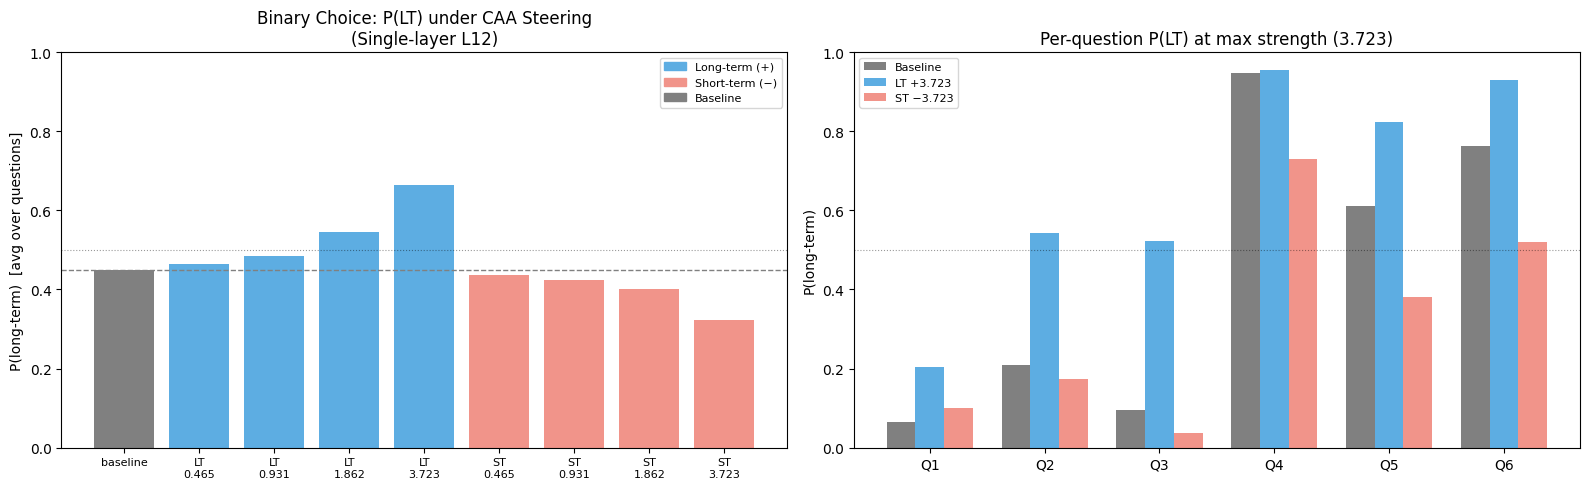


Condition               Q1    Q2    Q3    Q4    Q5    Q6    Mean
------------------------------------------------------------------------------
baseline                0.065  0.209  0.095  0.947  0.612  0.764  0.449
LT_0.465                0.059  0.220  0.118  0.956  0.641  0.798  0.465
LT_0.931                0.057  0.234  0.150  0.964  0.676  0.833  0.486
LT_1.862                0.063  0.288  0.269  0.975  0.772  0.905  0.545
LT_3.723                0.204  0.543  0.523  0.956  0.822  0.930  0.663
ST_0.465                0.072  0.204  0.077  0.937  0.593  0.731  0.436
ST_0.931                0.078  0.197  0.061  0.931  0.574  0.703  0.424
ST_1.862                0.087  0.185  0.040  0.928  0.527  0.637  0.401
ST_3.723                0.100  0.173  0.037  0.731  0.381  0.519  0.324

Saved: /content/temporal-awareness/out/experiments/week3_steering/binary_choice_results.json


In [48]:
if W3_RUN_BINARY_CHOICE and bc_results:
    import matplotlib.patches as mpatches

    bc_labels = [label for label, _ in BC_CONDITIONS]
    avg_p_lt  = {
        label: np.mean([r["conditions"][label] for r in bc_results])
        for label in bc_labels
    }
    baseline_p = avg_p_lt["baseline"]

    def _bc_colour(label: str) -> str:
        if label == "baseline":  return "gray"
        if label.startswith("LT_"): return "#5dade2"
        return "#f1948a"

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # ── Left: average P(LT) per condition ─────────────────────────────────────
    ax = axes[0]
    bars = ax.bar(
        range(len(bc_labels)),
        [avg_p_lt[l] for l in bc_labels],
        color=[_bc_colour(l) for l in bc_labels],
    )
    ax.axhline(baseline_p, color="gray", linestyle="--", linewidth=1,
               label=f"Baseline ({baseline_p:.3f})")
    ax.axhline(0.5, color="black", linestyle=":", linewidth=0.8, alpha=0.4)
    ax.set_xticks(range(len(bc_labels)))
    ax.set_xticklabels([l.replace("_", "\n") for l in bc_labels], fontsize=8)
    ax.set_ylabel("P(long-term)  [avg over questions]")
    ax.set_title(f"Binary Choice: P(LT) under CAA Steering\n({_mode_label})")
    ax.set_ylim(0, 1)
    ax.legend(handles=[
        mpatches.Patch(color="#5dade2", label="Long-term (+)"),
        mpatches.Patch(color="#f1948a", label="Short-term (−)"),
        mpatches.Patch(color="gray",    label="Baseline"),
    ], fontsize=8, loc="upper right")

    # ── Right: P(LT) per question at strongest strength ────────────────────────
    ax = axes[1]
    _strongest = W3_STRENGTHS[-1]
    _lt_label  = f"LT_{_strongest}"
    _st_label  = f"ST_{_strongest}"
    q_labels   = [f"Q{i+1}" for i in range(len(bc_results))]
    p_base     = [r["conditions"]["baseline"] for r in bc_results]
    p_lt_strong = [r["conditions"].get(_lt_label, float("nan")) for r in bc_results]
    p_st_strong = [r["conditions"].get(_st_label, float("nan")) for r in bc_results]
    x = np.arange(len(q_labels))
    w = 0.25
    ax.bar(x - w, p_base,      width=w, label="Baseline",       color="gray")
    ax.bar(x,     p_lt_strong, width=w, label=f"LT +{_strongest}", color="#5dade2")
    ax.bar(x + w, p_st_strong, width=w, label=f"ST −{_strongest}", color="#f1948a")
    ax.axhline(0.5, color="black", linestyle=":", linewidth=0.8, alpha=0.4)
    ax.set_xticks(x)
    ax.set_xticklabels(q_labels)
    ax.set_ylabel("P(long-term)")
    ax.set_title(f"Per-question P(LT) at max strength ({_strongest})")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(W3_OUT_DIR / "binary_choice_p_longterm.png", dpi=150)
    plt.show()

    # ── Numeric table ──────────────────────────────────────────────────────────
    print(f"\n{'Condition':<22}", end="")
    for qi in range(len(bc_results)):
        print(f"  Q{qi+1}  ", end="")
    print("  Mean")
    print("-" * (22 + 8 * len(bc_results) + 8))
    for label in bc_labels:
        vals = [bc_results[qi]["conditions"][label] for qi in range(len(bc_results))]
        print(f"{label:<22}", end="")
        for v in vals:
            print(f"  {v:.3f}", end="")
        print(f"  {np.mean(vals):.3f}")

    # ── Save ───────────────────────────────────────────────────────────────────
    with open(W3_OUT_DIR / "binary_choice_results.json", "w") as f:
        json.dump({
            "mode": W3_STEERING_MODE,
            "steer_layers": _steer_layers_active,
            "strengths": W3_STRENGTHS,
            "questions": BINARY_QUESTIONS,
            "results": bc_results,
        }, f, indent=2)
    print(f"\nSaved: {W3_OUT_DIR / 'binary_choice_results.json'}")

## Week 3 Summary

| Parameter | Value |
|-----------|-------|
| Steering mode | `W3_STEERING_MODE` |
| Layer(s) steered | `W3_STEER_LAYER` (single) / `W3_STEER_LAYERS` (multi) |
| Strengths (frac) | `W3_STRENGTHS_FRAC` |
| Strengths (absolute) | resolved from fracs × mean residual norm |
| Prompts active | selected by `W3_PROMPT_SET` / `W3_SELECTED_PROMPTS` |

### Reading the results

| Signal | Interpretation |
|--------|----------------|
| Text shifts clearly at 20–40% strength | Layer genuinely encodes temporal horizon |
| Text shifts only at 40% or incoherent | Subspace shallow; try a different layer or higher absolute strength |
| No detectable change | Wrong layer, wrong sign, or strength too small |
| Repetition / word salad | Overshooting; reduce `W3_STRENGTHS_FRAC` or try greedy (`W3_TEMPERATURE=0`) |
| Binary P(LT) moves monotonically with strength | Clean quantitative confirmation |
| Binary P(LT) flat | Baseline too extreme (> 0.9 or < 0.1); replace that question |

### Debugging weak steering

1. **Increase strength**: try `W3_STRENGTHS_FRAC = [0.20, 0.40, 0.80]` or `W3_STRENGTHS_ABSOLUTE = [10.0, 20.0, 40.0]`
2. **Try different layers**: change `W3_STEER_LAYER` to 8, 14, 16, or 20 and compare
3. **Multi-layer at full strength**: set `W3_STEERING_MODE = "multi"` — each layer now gets full strength, not divided
4. **Greedy decoding**: set `W3_TEMPERATURE = 0` to eliminate sampling noise for qualitative checks
5. **Check vector sign**: if LT and ST completions look swapped, negate the CAA direction

### Next Steps (Week 4)
- SAE decomposition: which features at the steering layer project maximally onto `caa_vec_unit`?
- Transfer test: does the direction generalize to `Llama-3.1-8B-Instruct` (post-SFT)?
- Cosine similarity of completions to temporal anchor embeddings (quantitative scoring)